# Laboratorio 4 — Agrupación: VuelaAlpes

**Curso:** ISIS2611 — Aprendizaje de Máquina  
**Fecha:** 11 de mayo de 2026  
**Integrantes:**
- Cristian Felipe Ochoa Osorio
- Ana Sofía Padilla Daza

---

### Descripción

VuelaAlpes es una aerolínea con operaciones en los Alpes y vuelos internacionales. Tras dos años de baja productividad, inició un proceso de mejora continua basado en encuestas a pasajeros. El objetivo de este laboratorio es aplicar técnicas de **agrupación (clustering)** para identificar patrones de comportamiento que permitan caracterizar distintos tipos de pasajeros, apoyando decisiones en innovación, capacitación y calidad del servicio.

**Actividades:**
1. Exploración y limpieza de datos
2. Modelamiento: Algoritmo K-Means
3. Modelamiento: Algoritmo Agglomerative Clustering
4. Modelamiento: Algoritmo DBSCAN
5. Tabla comparativa y selección del mejor modelo
6. Evaluación cualitativa e interpretación de los grupos
7. Análisis de resultados
8. Uso de IAG


# Falta por hacer
- [ ] Limpieza de datos
- [ ] Algo 1 — K-Means
- [ ] Algo 2 — Agglomerative Clustering
- [ ] Algo 3 — DBSCAN
- [ ] Tabla comparativa
- [ ] Evaluación cualitativa
- [ ] Respuesta preguntas
- [ ] Uso de IAG
- [ ] Video


## 0. Librerías

In [75]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn — preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Scikit-learn — clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Scikit-learn — evaluación
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

# Scipy — dendrogramas
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ── Configuración global ───────────────────────────────────────────────────────
RANDOM_STATE = 42
DATA_PATH    = './Datos_VuelaAlpes.csv'

np.random.seed(RANDOM_STATE)

# Diccionario para almacenar resultados comparativos
resultados = {}

os.makedirs('./outputs', exist_ok=True)
print("✅ Librerías cargadas correctamente.")


✅ Librerías cargadas correctamente.


## 1. Exploración de los Datos

Aplicamos la metodología CRISP-ML. En esta etapa cargamos el dataset e inspeccionamos su estructura, calidad e información relevante **antes de cualquier transformación**. Evaluamos cuatro dimensiones de calidad:

- **Completitud:** valores nulos o faltantes
- **Unicidad:** registros duplicados
- **Consistencia:** valores que contradicen reglas de dominio
- **Validez:** valores fuera de rangos esperados / outliers


### 1.1 Carga del Dataset

In [76]:
df = pd.read_csv(DATA_PATH, sep=',', encoding='latin-1')

print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nTipos de datos:")
print(df.dtypes.to_string())
print(f"\n--- Primeras 3 filas ---")
display(df.head(3))


Shape: 10,000 filas × 23 columnas

Tipos de datos:
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Depa

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0


### 1.2 Estadísticas Descriptivas

In [77]:
print("=== RESUMEN VARIABLES NUMÉRICAS ===")
display(df.describe().round(2))

print("\n=== RESUMEN VARIABLES CATEGÓRICAS ===")
display(df.describe(include='object'))


=== RESUMEN VARIABLES NUMÉRICAS ===


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9975.00
mean,64983.06,39.40,1196.04,2.73,3.07,2.76,3.00,3.22,3.23,3.43,3.36,3.39,3.34,3.64,3.29,3.64,3.28,14.86,15.22
std,37610.21,15.07,1000.59,1.33,1.52,1.39,1.28,1.32,1.35,1.31,1.33,1.29,1.32,1.18,1.26,1.18,1.31,36.78,37.37
min,1.00,7.00,31.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00
25%,32452.00,27.00,416.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00,2.00,3.00,2.00,0.00,0.00
50%,64815.50,40.00,846.00,3.00,3.00,3.00,3.00,3.00,3.00,4.00,4.00,4.00,4.00,4.00,3.00,4.00,3.00,0.00,0.00
75%,97470.00,51.00,1744.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,4.00,5.00,4.00,13.00,13.00
max,129879.00,80.00,4963.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,930.00,952.00



=== RESUMEN VARIABLES CATEGÓRICAS ===


,Gender,Customer Type,Type of Travel,Class
count,10000,10000,10000,10000
unique,2,2,2,3
top,Female,Loyal Customer,Business travel,Business
freq,5140,8155,6934,4856


### 1.3 Completitud — Valores Nulos

Identificamos columnas con datos faltantes y su porcentaje respecto al total.


⚠️  1 columnas con valores nulos:



,Nulos,Porcentaje (%)
Arrival Delay in Minutes,25,0.25


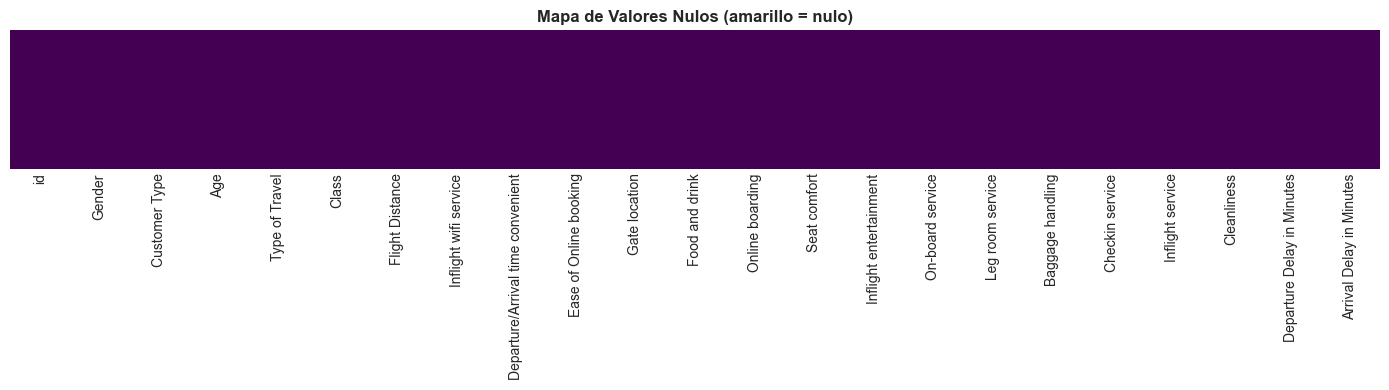

In [78]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
df_nulos = df_nulos[df_nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

if df_nulos.empty:
    print("✅ No se encontraron valores nulos.")
else:
    print(f"⚠️  {len(df_nulos)} columnas con valores nulos:\n")
    display(df_nulos)

# Heatmap de nulos
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos (amarillo = nulo)', fontweight='bold')
plt.tight_layout()
plt.show()


### 1.4 Unicidad — Duplicados

Verificamos si existen registros idénticos en el dataset.


In [79]:
n_dup = df.duplicated().sum()
print(f"Registros duplicados: {n_dup} ({n_dup/len(df)*100:.2f}%)")

if n_dup > 0:
    print("\nEjemplos de duplicados:")
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(6))
else:
    print("✅ No se encontraron filas duplicadas.")


Registros duplicados: 0 (0.00%)
✅ No se encontraron filas duplicadas.


### 1.5 Consistencia — Variables Categóricas

Revisamos los valores únicos de cada variable categórica para detectar errores tipográficos, categorías inesperadas o inconsistencias con el diccionario de datos.


In [80]:
cols_cat = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables categóricas: {len(cols_cat)}\n")
for col in cols_cat:
    vals = df[col].value_counts(dropna=False)
    print(f"── {col} ({df[col].nunique()} valores únicos) ──")
    print(vals.to_string())
    print()


Variables categóricas: 4

── Gender (2 valores únicos) ──
Gender
Female    5140
Male      4860

── Customer Type (2 valores únicos) ──
Customer Type
Loyal Customer       8155
disloyal Customer    1845

── Type of Travel (2 valores únicos) ──
Type of Travel
Business travel    6934
Personal Travel    3066

── Class (3 valores únicos) ──
Class
Business    4856
Eco         4442
Eco Plus     702



### 1.6 Validez — Outliers en Variables Numéricas

Usamos el método IQR para detectar valores atípicos. Un valor es outlier si está fuera del rango $[Q_1 - 1.5 \cdot IQR, \; Q_3 + 1.5 \cdot IQR]$.


In [81]:
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_resumen = []
for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_resumen.append({
        'Variable': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Límite Inf.': round(lower, 2), 'Límite Sup.': round(upper, 2),
        'N Outliers': n_out,
        '% Outliers': round(n_out / len(df) * 100, 2)
    })

#df_outliers = pd.DataFrame(outlier_resumen).sort_values('N Outliers', ascending=False)
#display(df_outliers)

df_outliers = pd.DataFrame(outlier_resumen)

print(df_outliers.columns)
display(df_outliers.head())


Index(['Variable', 'Q1', 'Q3', 'IQR', 'Límite Inf.', 'Límite Sup.',
       'N Outliers', '% Outliers'],
      dtype='object')


,Variable,Q1,Q3,IQR,Límite Inf.,Límite Sup.,N Outliers,% Outliers
0,id,32452.0,97470.0,65018.0,-65075.0,194997.0,0,0.00
1,Age,27.0,51.0,24.0,-9.0,87.0,0,0.00
2,Flight Distance,416.0,1744.0,1328.0,-1576.0,3736.0,223,2.23
3,Inflight wifi service,2.0,4.0,2.0,-1.0,7.0,0,0.00
4,Departure/Arrival time convenient,2.0,4.0,2.0,-1.0,7.0,0,0.00


#### Boxplots de Variables Numéricas

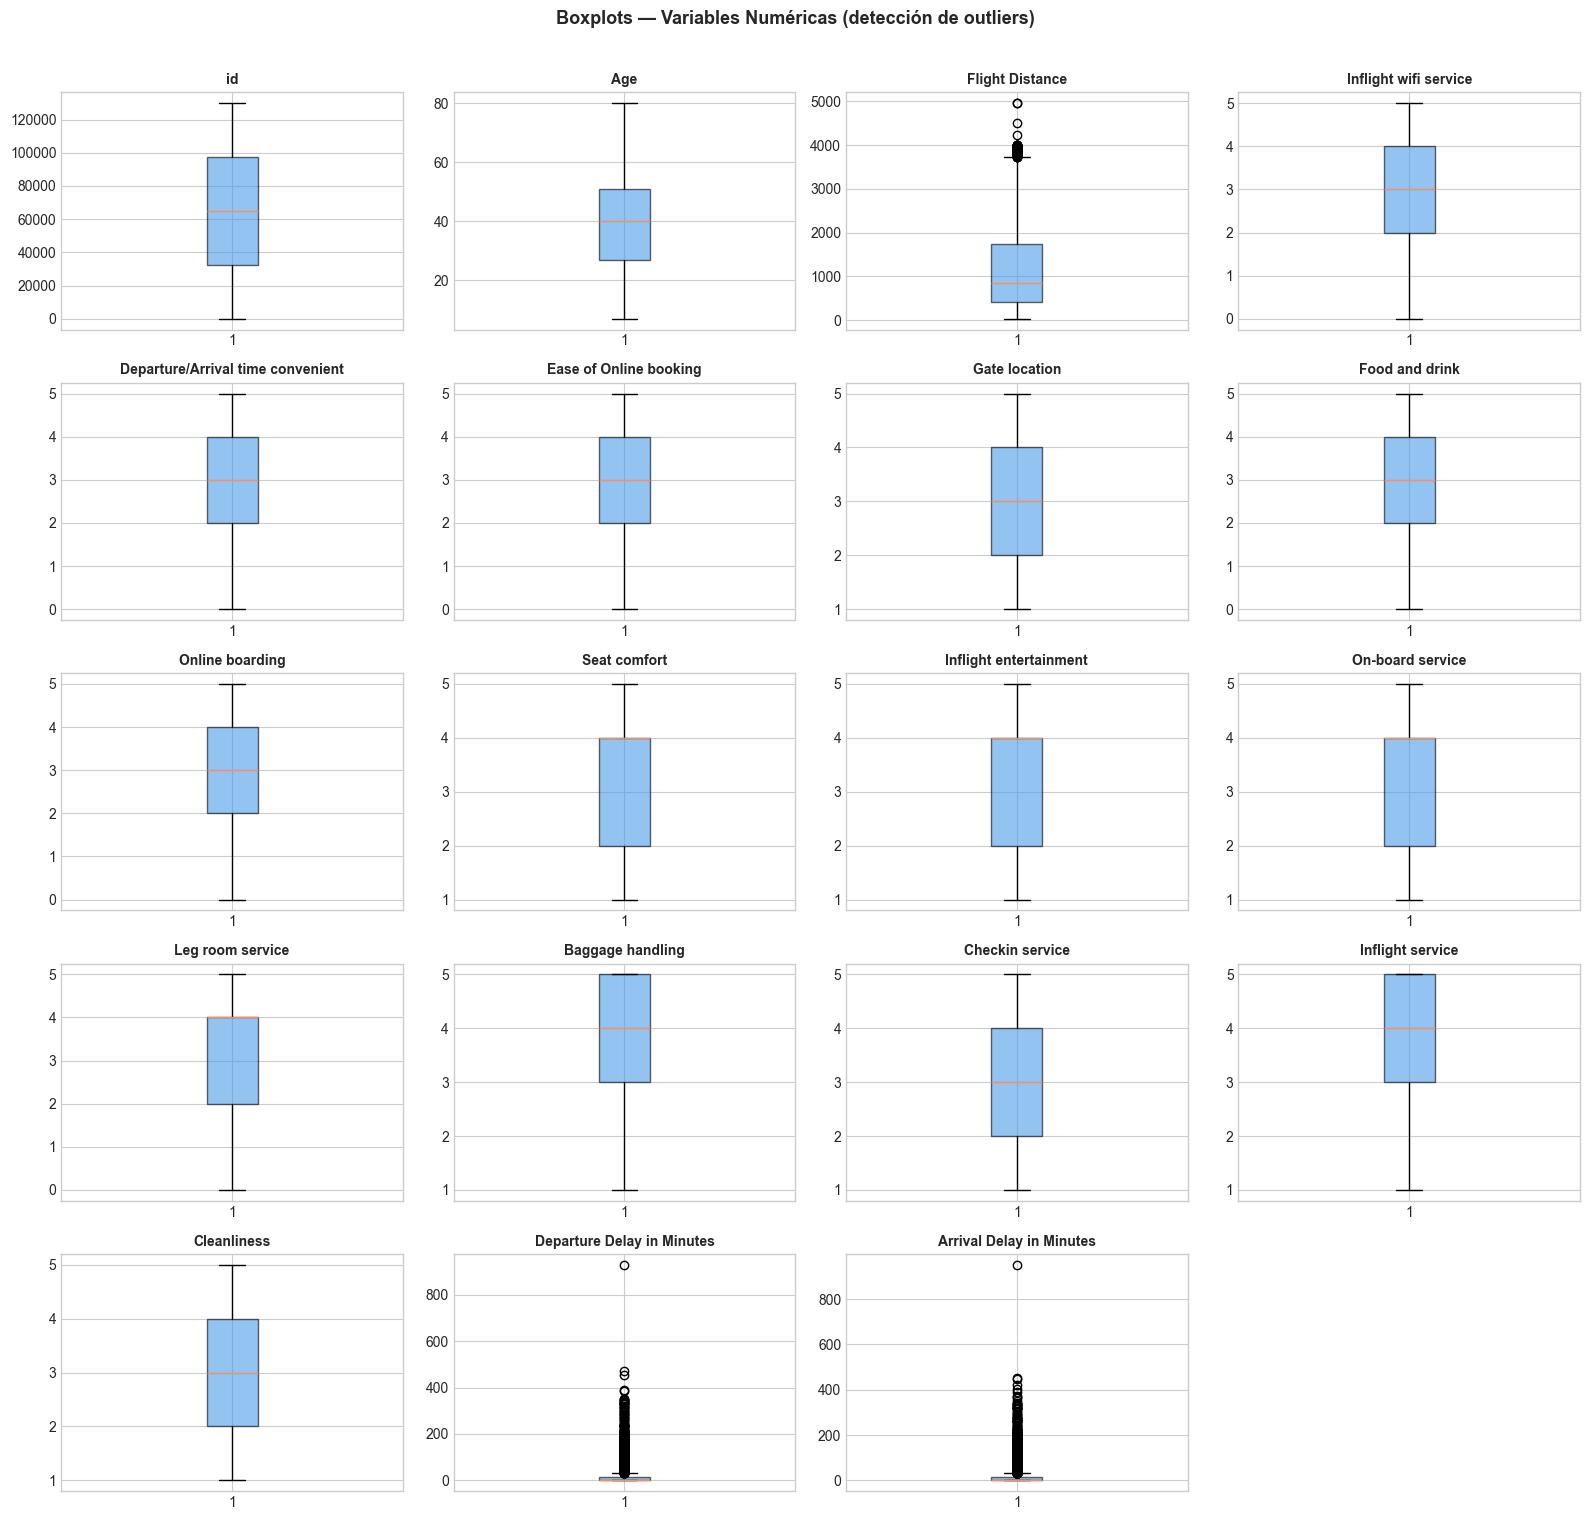

In [82]:
n = len(cols_num)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C9BE8', alpha=0.6))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Variables Numéricas (detección de outliers)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.7 Distribuciones de Variables Numéricas

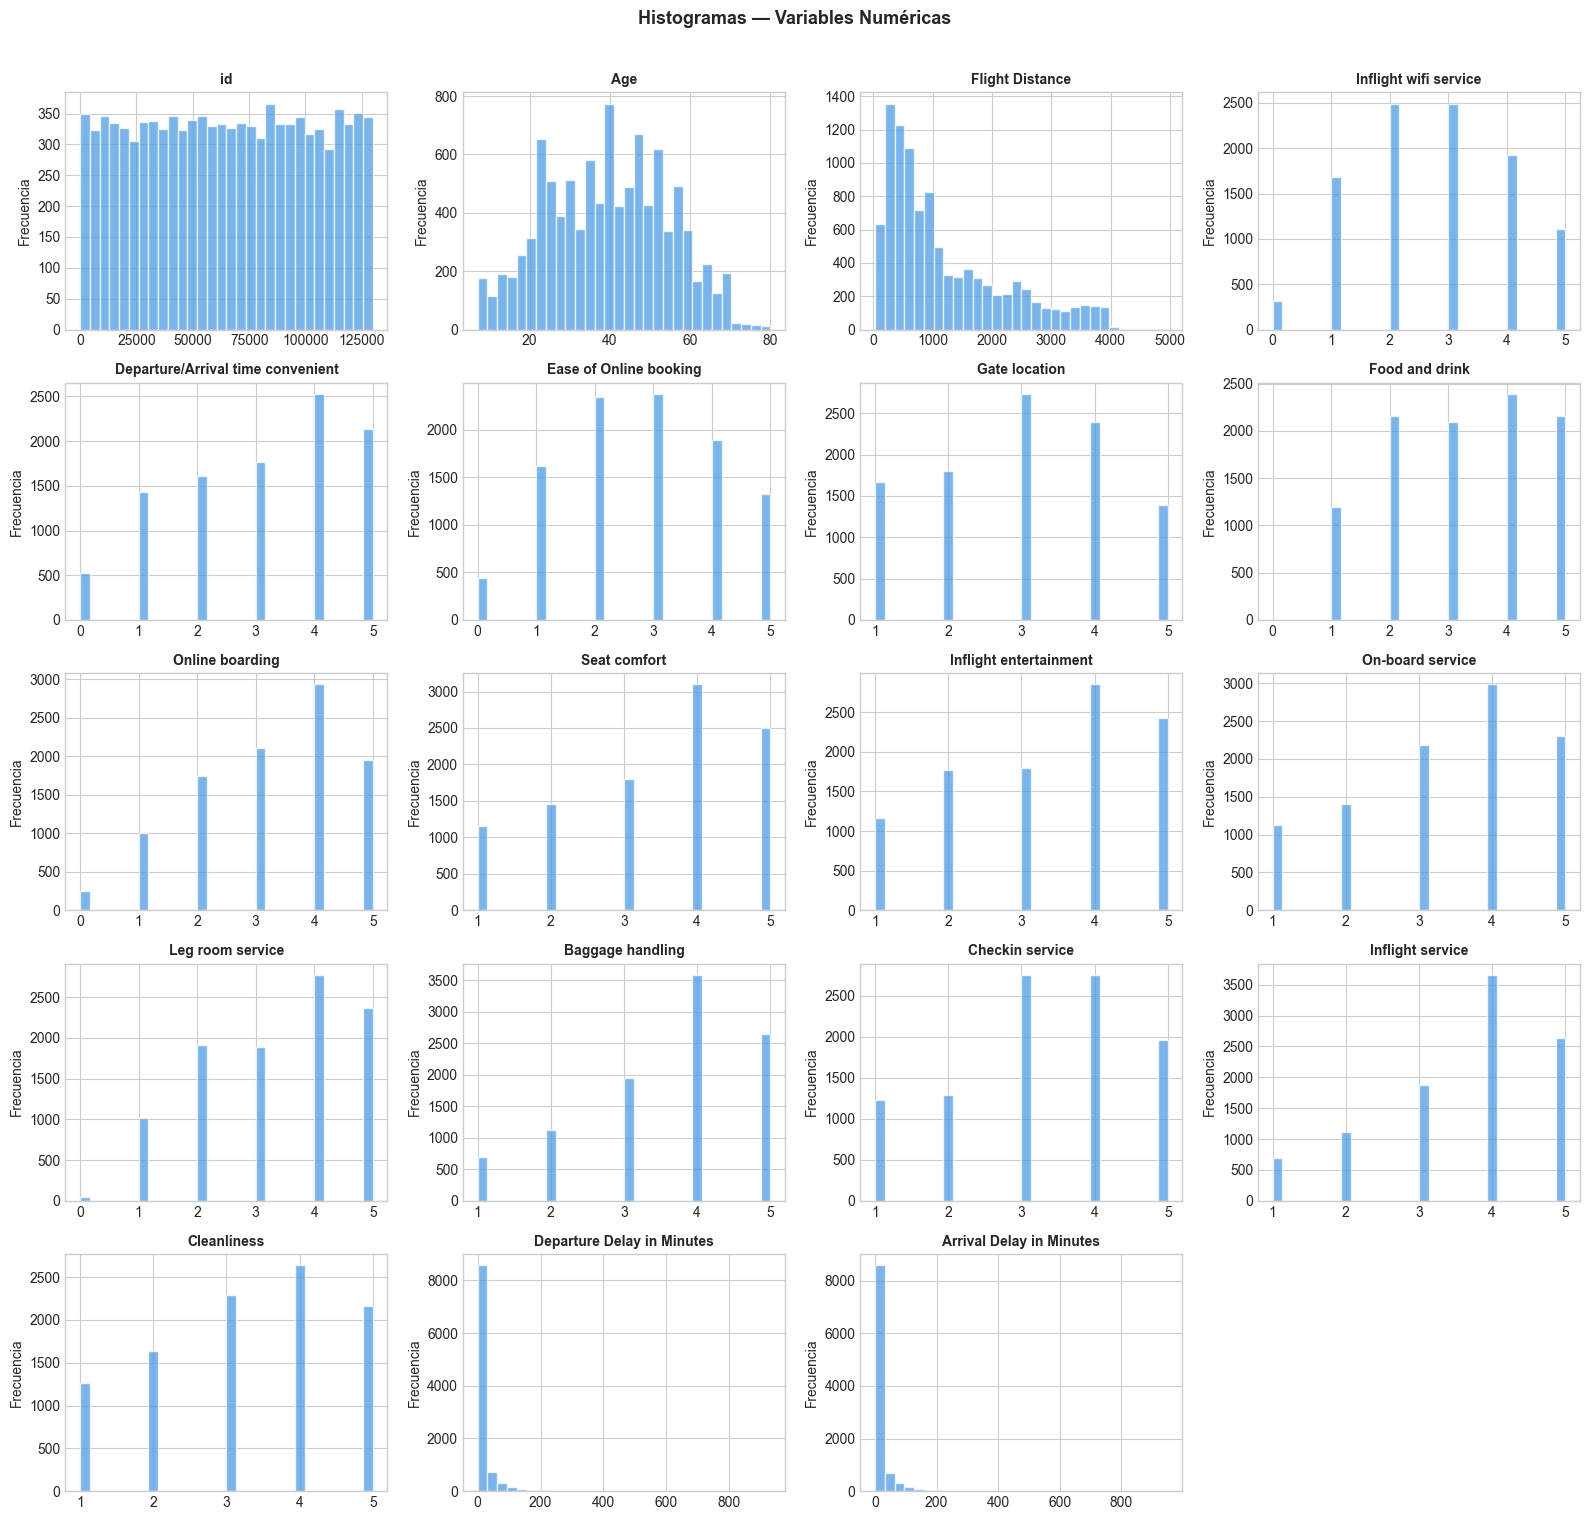

In [83]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].hist(df[col].dropna(), bins=30, color='#4C9BE8', edgecolor='white', alpha=0.75)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas — Variables Numéricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.8 Distribuciones de Variables Categóricas

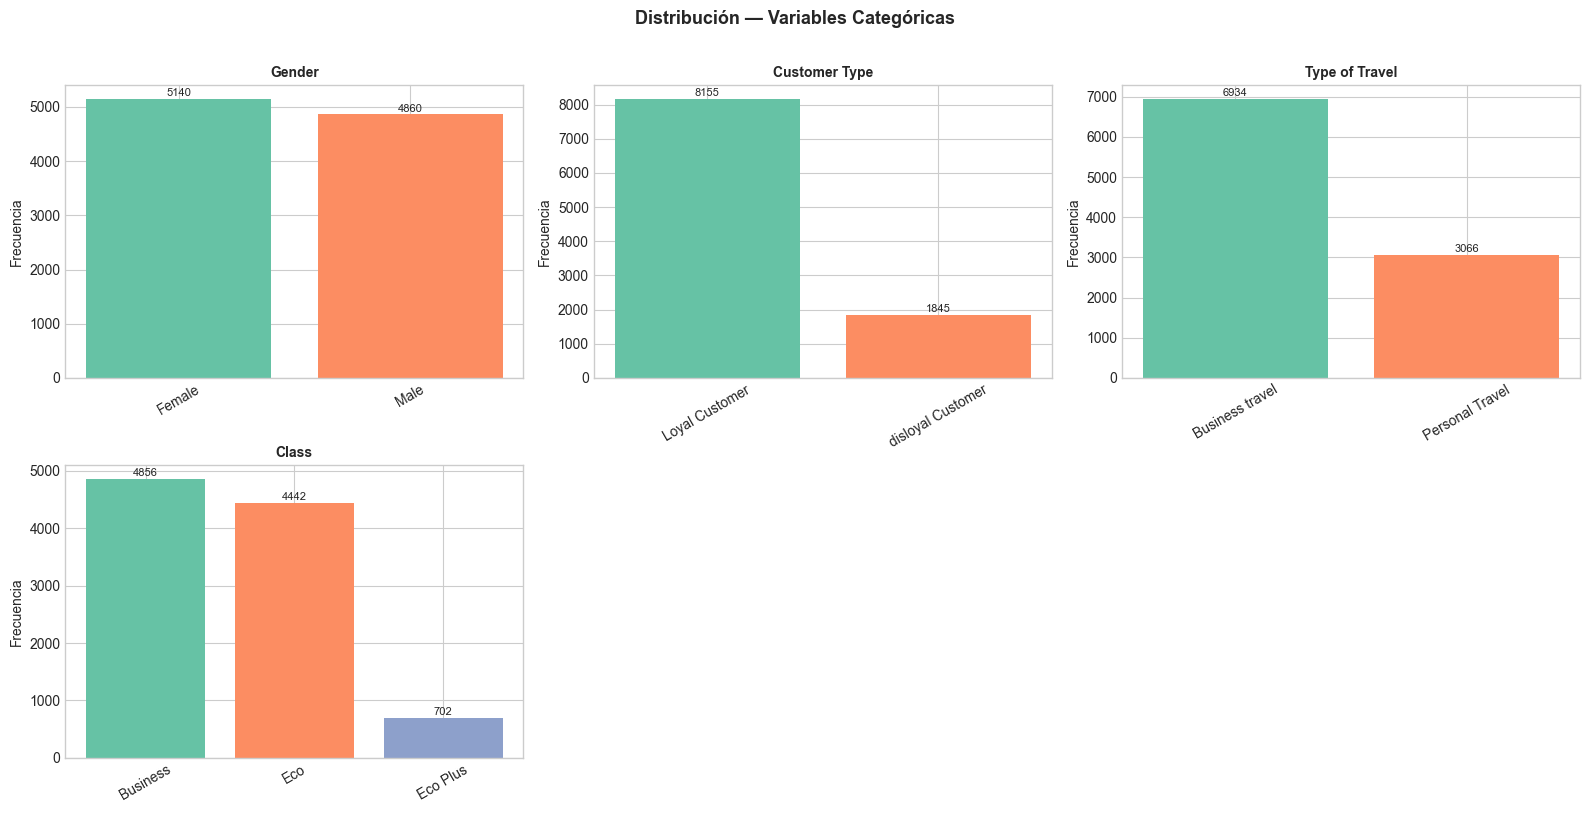

In [84]:
n_cat = len(cols_cat)
ncols_cat = 3
nrows_cat = (n_cat + ncols_cat - 1) // ncols_cat

fig, axes = plt.subplots(nrows_cat, ncols_cat, figsize=(16, nrows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    counts = df[col].value_counts(dropna=False)
    axes[i].bar(counts.index.astype(str), counts.values, 
                color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)
    for k, v in enumerate(counts.values):
        axes[i].text(k, v + max(counts.values) * 0.01, str(v), ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución — Variables Categóricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.9 Correlaciones entre Variables Numéricas

Una matriz de correlación permite identificar relaciones lineales entre variables, lo que también ayuda a detectar **redundancia** (variables altamente correlacionadas que aportan información similar al modelo).


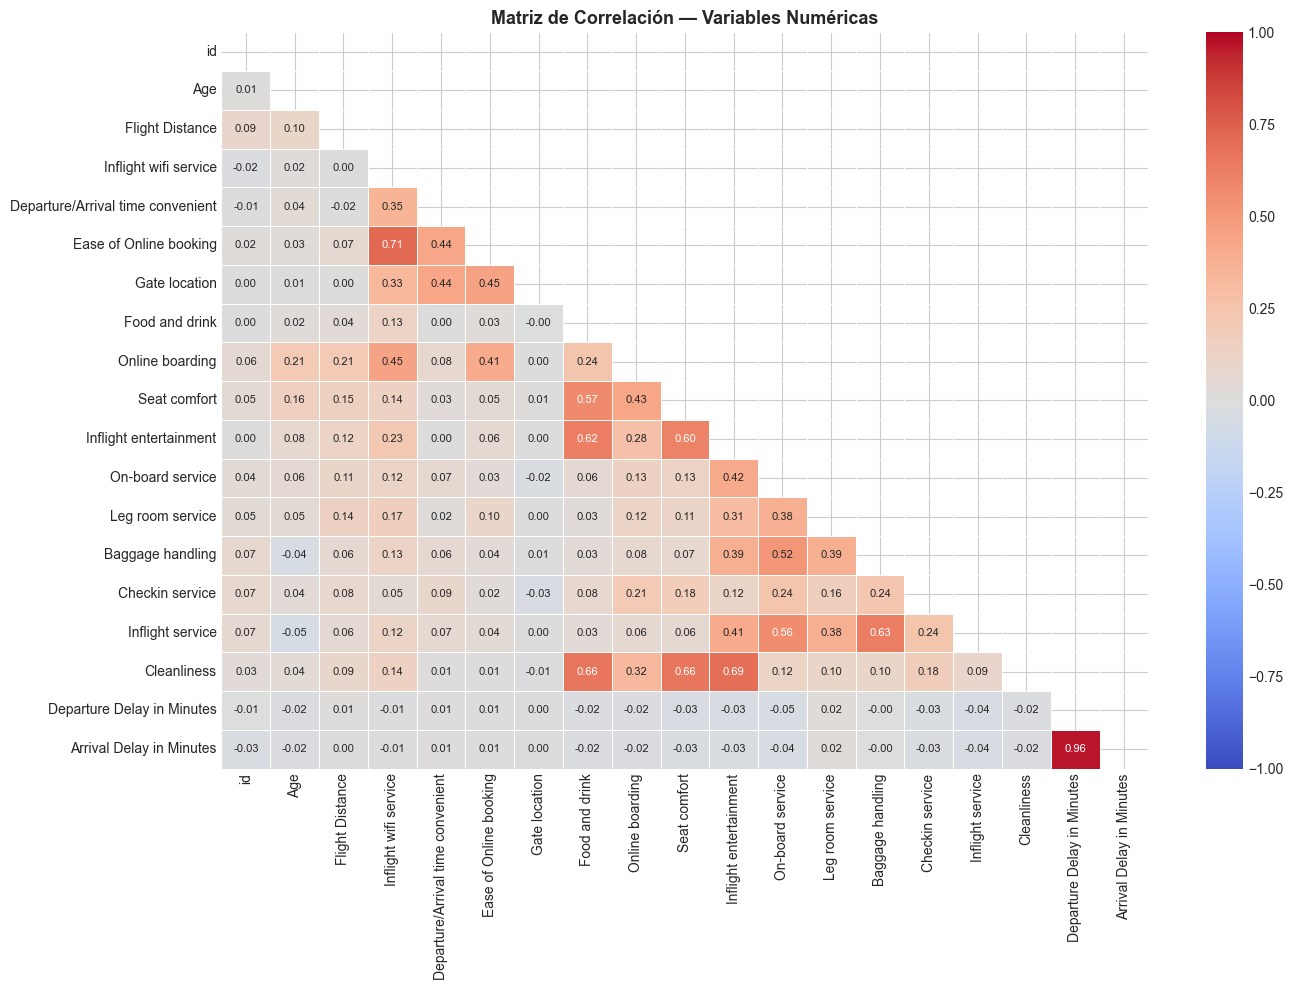

Pares con correlación |r| > 0.7:
  Ease of Online booking  ↔  Inflight wifi service  →  r = 0.714
  Arrival Delay in Minutes  ↔  Departure Delay in Minutes  →  r = 0.962


In [85]:
corr_matrix = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pares con alta correlación
print("Pares con correlación |r| > 0.7:")
for col_a in corr_matrix.columns:
    for col_b in corr_matrix.columns:
        if col_a < col_b:
            r = corr_matrix.loc[col_a, col_b]
            if abs(r) > 0.7:
                print(f"  {col_a}  ↔  {col_b}  →  r = {r:.3f}")


### 1.10 Variable de Satisfacción

Aunque en clustering no usamos una variable objetivo (es aprendizaje no supervisado), la columna `satisfaction` puede usarse como referencia **cualitativa** para validar los grupos obtenidos.


In [86]:
if 'satisfaction' in df.columns:
    counts = df['satisfaction'].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', 2))
    ax.set_title('Distribución de Satisfacción', fontweight='bold')
    ax.set_ylabel('Frecuencia')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, str(v), ha='center')
    plt.tight_layout()
    plt.show()
    print(counts)
    print(f"\nDesbalance: {counts.max()/counts.min():.2f}x")
else:
    print("Columna 'satisfaction' no encontrada — verificar nombre exacto en el dataset.")


Columna 'satisfaction' no encontrada — verificar nombre exacto en el dataset.


## 2. Limpieza y Preparación de Datos

Con base en los hallazgos de la exploración, aplicamos una serie de transformaciones justificadas. Las decisiones siguen los requerimientos de los algoritmos de agrupación que usaremos: **K-Means, Agglomerative Clustering y DBSCAN**.

### Tabla de Problemas Identificados y Decisiones Tomadas

| Variable | Dimensión | Problema Identificado | Decisión | Justificación |
|---|---|---|---|---|
| `Unnamed: 0` / `id` | Unicidad | Columna de índice sin valor predictivo | **Eliminar** | No aporta información al modelo |
| `satisfaction` | Relevancia | Variable de resultado (no usada en clustering) | **Separar** como referencia cualitativa | El clustering es no supervisado; no debe influir el agrupamiento |
| `Arrival Delay in Minutes` | Completitud | Valores nulos (~0.3%) | **Imputar con mediana** | Porcentaje bajo; la mediana es robusta a outliers |
| Variables de calificación [0-5] | Validez | Posibles valores fuera del rango permitido | **Recortar a [0,5]** | El diccionario define escala 0-5 |
| Variables numéricas | Escalamiento | Distintas magnitudes | **StandardScaler** | K-Means y DBSCAN son sensibles a la escala |
| Variables categóricas (`Gender`, `Customer Type`, `Type of Travel`, `Class`) | Codificación | Texto; no interpretable numéricamente | **OneHotEncoder** | Evita orden artificial; compatible con distancia euclidiana |


### 2.1 Limpieza

In [87]:
df_clean = df.copy()

# ── 1. Eliminar columnas no pertinentes ────────────────────────────────────────
# Columna índice (si existe)
drop_cols = [c for c in df_clean.columns if c.lower() in ['unnamed: 0', 'id']]
if drop_cols:
    df_clean.drop(columns=drop_cols, inplace=True)
    print(f"🗑️  Columnas índice eliminadas: {drop_cols}")

# ── 2. Separar variable de referencia (satisfacción) ──────────────────────────
if 'satisfaction' in df_clean.columns:
    satisfaction_ref = df_clean['satisfaction'].copy()
    df_clean.drop(columns=['satisfaction'], inplace=True)
    print(f"ℹ️  'satisfaction' separada como referencia cualitativa ({satisfaction_ref.nunique()} valores únicos).")

# ── 3. Tratar valores nulos ────────────────────────────────────────────────────
nulos_antes = df_clean.isnull().sum().sum()
# Imputar columnas numéricas con mediana (robusto a outliers)
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().any():
        mediana = df_clean[col].median()
        df_clean[col].fillna(mediana, inplace=True)
        print(f"  → '{col}': nulos imputados con mediana ({mediana:.2f})")

# Imputar columnas categóricas con moda
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().any():
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f"  → '{col}': nulos imputados con moda ('{moda}')")

nulos_despues = df_clean.isnull().sum().sum()
print(f"\n✅ Nulos antes: {nulos_antes} | Después: {nulos_despues}")

# ── 4. Eliminar duplicados ─────────────────────────────────────────────────────
n_dup = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"\n🗑️  Duplicados eliminados: {n_dup}")

# ── 5. Corregir valores de calificaciones fuera de rango [0,5] ────────────────
rating_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns
               if df_clean[c].max() <= 6 and df_clean[c].min() >= 0 and df_clean[c].nunique() <= 7]
for col in rating_cols:
    fuera = ((df_clean[col] < 0) | (df_clean[col] > 5)).sum()
    if fuera > 0:
        df_clean[col] = df_clean[col].clip(0, 5)
        print(f"  → '{col}': {fuera} valores recortados al rango [0,5]")

print(f"\nShape final: {df_clean.shape[0]:,} × {df_clean.shape[1]}")


🗑️  Columnas índice eliminadas: ['id']
  → 'Arrival Delay in Minutes': nulos imputados con mediana (0.00)

✅ Nulos antes: 25 | Después: 0

🗑️  Duplicados eliminados: 0

Shape final: 10,000 × 22


### 2.2 Clasificación de Variables para el Preprocessor

In [88]:
# Separar features por tipo
COLS_NUM = df_clean.select_dtypes(include=[np.number]).columns.tolist()
COLS_CAT = df_clean.select_dtypes(include='object').columns.tolist()

# Columnas binarias (0/1 o dos únicos valores)
COLS_BIN = [c for c in COLS_NUM if df_clean[c].nunique() == 2 and set(df_clean[c].unique()).issubset({0,1})]
COLS_NUM_CONT = [c for c in COLS_NUM if c not in COLS_BIN]

print(f"Variables numéricas continuas ({len(COLS_NUM_CONT)}):")
print(f"  {COLS_NUM_CONT}")
print(f"\nVariables binarias ({len(COLS_BIN)}):")
print(f"  {COLS_BIN}")
print(f"\nVariables categóricas nominales ({len(COLS_CAT)}):")
print(f"  {COLS_CAT}")


Variables numéricas continuas (18):
  ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Variables binarias (0):
  []

Variables categóricas nominales (4):
  ['Gender', 'Customer Type', 'Type of Travel', 'Class']


### 2.3 Pipeline de Preprocesamiento

Construimos un `ColumnTransformer` reutilizable para todos los modelos de clustering. Las decisiones clave son:

- **StandardScaler** en variables numéricas: K-Means y DBSCAN usan distancia euclidiana, que es sensible a la escala. Sin escalamiento, una variable como `Flight Distance` dominaría sobre calificaciones [0-5].
- **OneHotEncoder** en categóricas: Genera representaciones binarias sin orden artificial, compatibles con la distancia euclidiana.
- **SimpleImputer** como salvaguarda adicional en caso de nulos residuales.


In [89]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Transformer para numéricas continuas
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Transformer para binarias (escalar sin one-hot)
bin_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  StandardScaler())
])

# Transformer para categóricas nominales
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Lista de transformers (solo incluimos los tipos que existen)
transformers = []
if COLS_NUM_CONT:
    transformers.append(('num', num_transformer, COLS_NUM_CONT))
if COLS_BIN:
    transformers.append(('bin', bin_transformer, COLS_BIN))
if COLS_CAT:
    transformers.append(('cat', cat_transformer, COLS_CAT))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Aplicar preprocesamiento y obtener matriz X_prep para análisis
X_raw  = df_clean.copy()
X_prep = preprocessor.fit_transform(X_raw)

print(f"✅ Preprocesamiento aplicado.")
print(f"   Shape original: {X_raw.shape}")
print(f"   Shape preprocesado: {X_prep.shape}  (columnas expandidas por OneHotEncoder)")


✅ Preprocesamiento aplicado.
   Shape original: (10000, 22)
   Shape preprocesado: (10000, 27)  (columnas expandidas por OneHotEncoder)


### 2.4 Reducción de Dimensionalidad con PCA (para visualización)

Dado que el espacio preprocesado tiene alta dimensionalidad (por el OneHotEncoding), utilizamos PCA a 2 y 3 componentes para **visualización exploratoria**. Esto no se usa como input de los modelos de clustering; los modelos trabajan sobre el espacio completo.


Varianza explicada PCA-2: 31.83%
Varianza explicada PCA-3: 42.94%


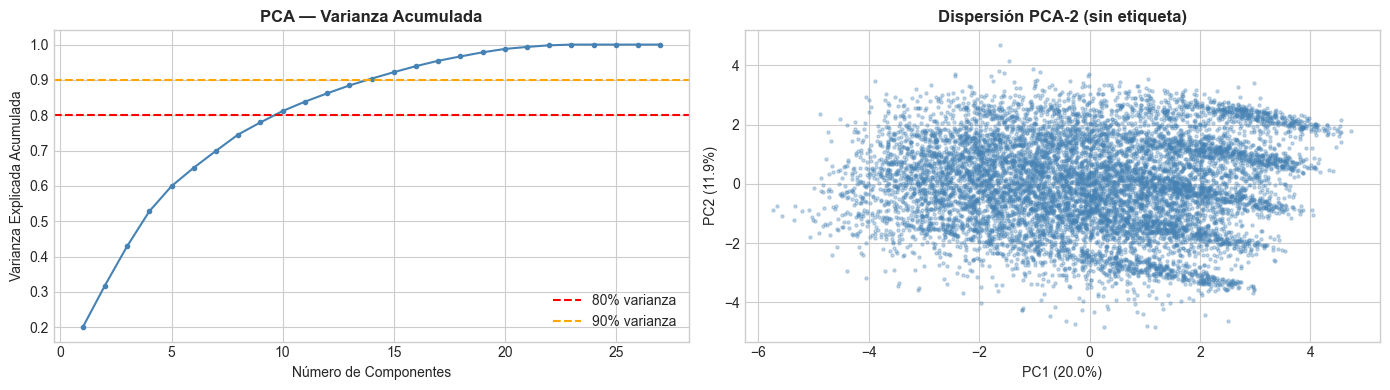


✅ X_prep y X_pca2 disponibles para los modelos de clustering.


In [90]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_prep)

pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_prep)

print(f"Varianza explicada PCA-2: {pca2.explained_variance_ratio_.sum():.2%}")
print(f"Varianza explicada PCA-3: {pca3.explained_variance_ratio_.sum():.2%}")

# Curva de varianza acumulada
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_prep)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Varianza acumulada
axes[0].plot(range(1, len(var_acum)+1), var_acum, 'o-', color='steelblue', markersize=3)
axes[0].axhline(0.80, color='red', linestyle='--', label='80% varianza')
axes[0].axhline(0.90, color='orange', linestyle='--', label='90% varianza')
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title('PCA — Varianza Acumulada', fontweight='bold')
axes[0].legend()

# Dispersión 2D (sin etiqueta de clusters aún)
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.3, s=5, color='steelblue')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Dispersión PCA-2 (sin etiqueta)', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ X_prep y X_pca2 disponibles para los modelos de clustering.")


### 2.5 Resumen del Proceso de Preparación

| Etapa | Acción | Resultado |
|---|---|---|
| Columnas índice | Eliminadas | Sin efecto en clustering |
| Variable `satisfaction` | Separada como referencia | No influye en agrupamiento |
| Valores nulos numéricos | Imputados con mediana | Robusto a outliers |
| Valores nulos categóricos | Imputados con moda | Categoría más frecuente |
| Duplicados | Eliminados | Dataset sin redundancias |
| Calificaciones fuera de [0,5] | Recortadas con `clip()` | Valores válidos |
| Variables numéricas | `StandardScaler` | Media 0, desv. 1 |
| Variables categóricas | `OneHotEncoder` | Compatibilidad distancia euclidiana |
| Reducción dimensional | `PCA` (solo visualización) | Exploración 2D/3D |

Los objetos disponibles para la fase de modelamiento son:

- `X_raw`: DataFrame original limpio  
- `X_prep`: Matriz numpy preprocesada (input de los modelos)  
- `X_pca2`: Proyección 2D para visualizaciones  
- `preprocessor`: Pipeline reutilizable para nuevas instancias  
- `satisfaction_ref`: Referencia cualitativa de satisfacción (si estaba disponible)  


### Función auxiliar de evaluación y visualización

In [91]:
def evaluar_modelo(nombre, labels, X_prep, X_pca2, satisfaction_ref=None):
    mask_validos = labels != -1
    n_clusters = len(set(labels[mask_validos]))
    n_ruido = (labels == -1).sum()
    resultado = {'Algoritmo': nombre, 'N Clusters': n_clusters, 'N Ruido': n_ruido}
    if n_clusters >= 2:
        resultado['Silhouette']        = round(silhouette_score(X_prep[mask_validos], labels[mask_validos]), 4)
        resultado['Calinski-Harabasz'] = round(calinski_harabasz_score(X_prep[mask_validos], labels[mask_validos]), 2)
        resultado['Davies-Bouldin']    = round(davies_bouldin_score(X_prep[mask_validos], labels[mask_validos]), 4)
    else:
        resultado['Silhouette'] = resultado['Calinski-Harabasz'] = resultado['Davies-Bouldin'] = np.nan
    print(f"\n{'='*55}\n  {nombre}\n{'='*55}")
    print(f"  Clusters encontrados : {n_clusters}")
    print(f"  Puntos ruido (-1)    : {n_ruido}  ({n_ruido/len(labels)*100:.1f}%)")
    print(f"  Silhouette Score     : {resultado['Silhouette']}")
    print(f"  Calinski-Harabasz    : {resultado['Calinski-Harabasz']}")
    print(f"  Davies-Bouldin       : {resultado['Davies-Bouldin']}")
    unique, counts = np.unique(labels, return_counts=True)
    print("\n  Distribucion de clusters:")
    for u, c in zip(unique, counts):
        lbl = "Ruido" if u == -1 else f"Cluster {u}"
        print(f"    {lbl}: {c:,} ({c/len(labels)*100:.1f}%)")
    palette = sns.color_palette('tab10', max(n_clusters,2))
    color_map = {lbl: palette[i] for i, lbl in enumerate(sorted(set(labels[mask_validos])))}
    color_map[-1] = (0.7, 0.7, 0.7)
    colors = [color_map[l] for l in labels]
    ncols = 2 if satisfaction_ref is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7*ncols, 5))
    if ncols == 1: axes = [axes]
    axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=colors, alpha=0.35, s=6)
    axes[0].set_title(f'{nombre} - Clusters en PCA-2D', fontweight='bold')
    axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
    from matplotlib.patches import Patch
    handles = [Patch(color=color_map[k], label=('Ruido' if k==-1 else f'Cluster {k}')) for k in sorted(color_map)]
    axes[0].legend(handles=handles, loc='best', fontsize=8)
    if satisfaction_ref is not None:
        sat_colors = ['#e74c3c' if s == 'dissatisfied' else '#2ecc71' for s in satisfaction_ref.values]
        axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=sat_colors, alpha=0.35, s=6)
        axes[1].set_title('Satisfaccion Real en PCA-2D (referencia)', fontweight='bold')
        axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
        axes[1].legend(handles=[Patch(color='#e74c3c', label='Disatisfecho'), Patch(color='#2ecc71', label='Satisfecho')], loc='best', fontsize=8)
    plt.tight_layout(); plt.show()
    return resultado

print("Funcion auxiliar definida.")


Funcion auxiliar definida.


# 3. Modelamiento — Algoritmos de Agrupación

En esta sección se implementan tres algoritmos de agrupación distintos utilizando pipelines y búsqueda de hiperparámetros:

1. K-Means  
2. Agglomerative Clustering  
3. DBSCAN  

Todos los modelos integran el preprocesamiento dentro de un flujo reproducible.

---
## Modelo 1 — K-Means

### Descripcion teorica

K-Means es un algoritmo de agrupacion **particional** que divide los datos en *k* clusters minimizando la inercia (suma de distancias cuadraticas al centroide mas cercano). Opera en tres pasos iterativos: (1) asignacion de cada punto al centroide mas cercano, (2) recalculo de centroides, (3) repeticion hasta convergencia.

**Restricciones y limitaciones:**
- Requiere especificar *k* a priori.
- Asume clusters **esfericos** y de tamano similar.
- Es sensible a la **escala** de las variables (requiere normalizacion).
- Puede converger a minimos locales (se mitiga con `n_init` repeticiones).
- No maneja bien outliers extremos (los asigna forzosamente a algun cluster).

**Hiperparametro a buscar:** numero optimo de clusters *k* mediante el metodo del codo e indice de Silhouette.


### 2.1.1 Busqueda de Hiperparametros — Codo y Silhouette

  k= 2 | Inercia: 169,922 | Sil: 0.1404 | CH: 1644.8 | DB: 2.3789
  k= 3 | Inercia: 157,950 | Sil: 0.1067 | CH: 1263.5 | DB: 2.4624
  k= 4 | Inercia: 147,081 | Sil: 0.1139 | CH: 1150.7 | DB: 2.1504
  k= 5 | Inercia: 137,381 | Sil: 0.1148 | CH: 1100.3 | DB: 2.1141
  k= 6 | Inercia: 130,922 | Sil: 0.1152 | CH: 1022.2 | DB: 2.0543
  k= 7 | Inercia: 126,707 | Sil: 0.1117 | CH: 935.5 | DB: 2.1706
  k= 8 | Inercia: 123,112 | Sil: 0.1068 | CH: 866.9 | DB: 2.2119
  k= 9 | Inercia: 120,296 | Sil: 0.1082 | CH: 805.4 | DB: 2.1893
  k=10 | Inercia: 117,719 | Sil: 0.1073 | CH: 755.8 | DB: 2.1892
  k=11 | Inercia: 115,724 | Sil: 0.1074 | CH: 709.1 | DB: 2.1421


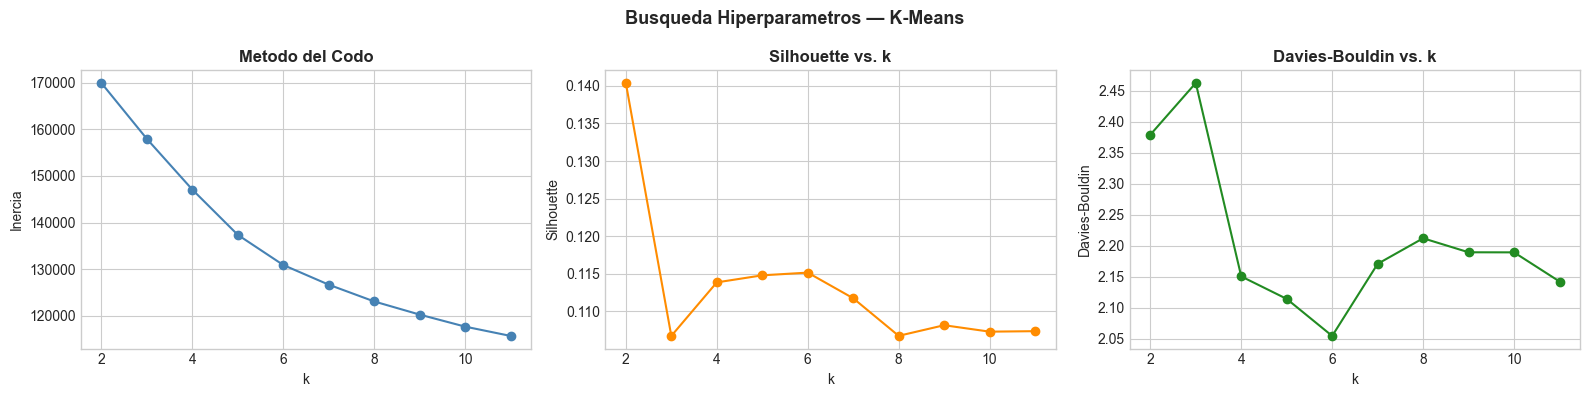


Mejor k seleccionado: 2  (Silhouette = 0.1404)


In [92]:
K_RANGE = range(2, 12)
inercias = []; sil_scores = []; ch_scores = []; db_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels_k = km.fit_predict(X_prep)
    inercias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_prep, labels_k))
    ch_scores.append(calinski_harabasz_score(X_prep, labels_k))
    db_scores.append(davies_bouldin_score(X_prep, labels_k))
    print(f"  k={k:2d} | Inercia: {km.inertia_:,.0f} | Sil: {sil_scores[-1]:.4f} | CH: {ch_scores[-1]:.1f} | DB: {db_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(list(K_RANGE), inercias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].set_title('Metodo del Codo', fontweight='bold')
axes[1].plot(list(K_RANGE), sil_scores, 'o-', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette vs. k', fontweight='bold')
axes[2].plot(list(K_RANGE), db_scores, 'o-', color='forestgreen')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin'); axes[2].set_title('Davies-Bouldin vs. k', fontweight='bold')
plt.suptitle('Busqueda Hiperparametros — K-Means', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f"\nMejor k seleccionado: {best_k}  (Silhouette = {max(sil_scores):.4f})")


### 2.1.2 Entrenamiento del Modelo Final K-Means (Pipeline reproducible)

In [93]:
pipeline_kmeans = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10, max_iter=300))
])
pipeline_kmeans.fit(X_raw)
kmeans_labels = pipeline_kmeans.named_steps['kmeans'].labels_

print(f"Pipeline K-Means entrenado.")
print(f"  n_clusters={best_k} | n_init=10 | max_iter=300 | random_state={RANDOM_STATE}")


Pipeline K-Means entrenado.
  n_clusters=2 | n_init=10 | max_iter=300 | random_state=42


### 2.1.3 Evaluacion y Visualizacion K-Means


  K-Means (k=2)
  Clusters encontrados : 2
  Puntos ruido (-1)    : 0  (0.0%)
  Silhouette Score     : 0.1404
  Calinski-Harabasz    : 1644.83
  Davies-Bouldin       : 2.3789

  Distribucion de clusters:
    Cluster 0: 4,573 (45.7%)
    Cluster 1: 5,427 (54.3%)


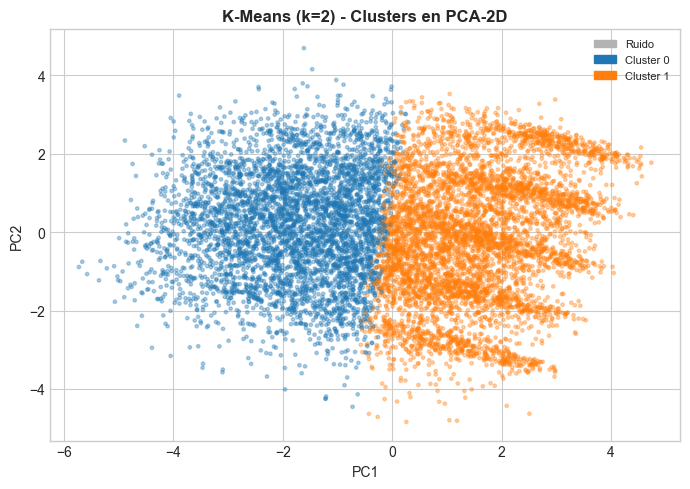

In [94]:
res_kmeans = evaluar_modelo(
    f'K-Means (k={best_k})', kmeans_labels, X_prep, X_pca2,
    satisfaction_ref if 'satisfaction_ref' in vars() else None
)
resultados['K-Means'] = res_kmeans


### 2.1.4 Perfiles de Clusters K-Means

=== PERFIL PROMEDIO POR CLUSTER ===


Cluster_KMeans,0,1
Age,37.47,41.03
Flight Distance,993.40,1366.80
Inflight wifi service,2.27,3.12
Departure/Arrival time convenient,2.95,3.18
Ease of Online booking,2.48,3.00
Gate location,2.96,3.04
Food and drink,2.44,3.87
Online boarding,2.57,3.79
Seat comfort,2.56,4.17
Inflight entertainment,2.27,4.28


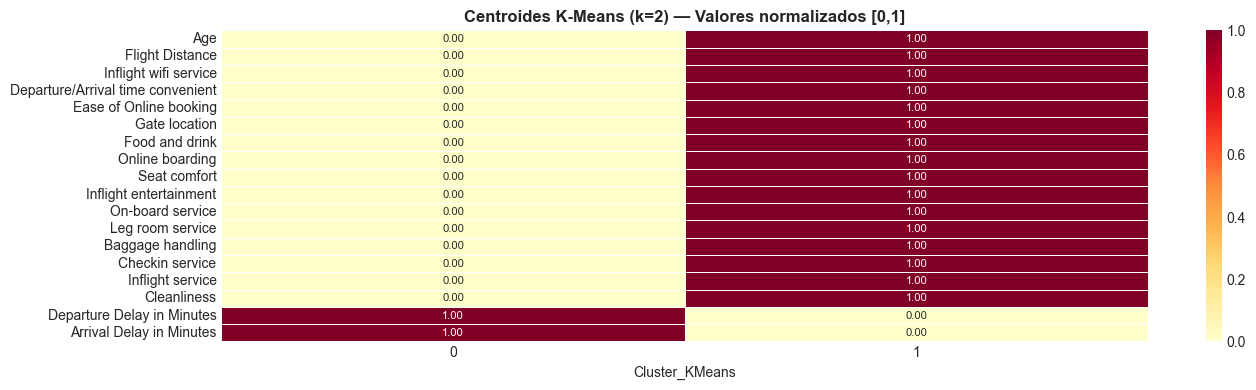


=== DISTRIBUCION CATEGORICA POR CLUSTER ===

Gender:


Gender,Female,Male
Cluster_KMeans,,
0,0.522,0.478
1,0.507,0.493



Customer Type:


Customer Type,Loyal Customer,disloyal Customer
Cluster_KMeans,,
0,0.761,0.239
1,0.861,0.139



Type of Travel:


Type of Travel,Business travel,Personal Travel
Cluster_KMeans,,
0,0.603,0.397
1,0.769,0.231


In [95]:
df_perfiles = X_raw.copy()
df_perfiles['Cluster_KMeans'] = kmeans_labels

print("=== PERFIL PROMEDIO POR CLUSTER ===")
display(df_perfiles.groupby('Cluster_KMeans')[COLS_NUM_CONT].mean().round(2).T)

from sklearn.preprocessing import MinMaxScaler
scaler_viz = MinMaxScaler()
centroids_raw = df_perfiles.groupby('Cluster_KMeans')[COLS_NUM_CONT].mean()
centroids_norm = pd.DataFrame(scaler_viz.fit_transform(centroids_raw),
    columns=COLS_NUM_CONT, index=centroids_raw.index)

fig, ax = plt.subplots(figsize=(14, max(4, best_k)))
sns.heatmap(centroids_norm.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Centroides K-Means (k={best_k}) — Valores normalizados [0,1]', fontweight='bold')
plt.tight_layout(); plt.show()

if COLS_CAT:
    print("\n=== DISTRIBUCION CATEGORICA POR CLUSTER ===")
    for col in COLS_CAT[:3]:
        ct = pd.crosstab(df_perfiles['Cluster_KMeans'], df_perfiles[col], normalize='index').round(3)
        print(f"\n{col}:"); display(ct)


### Preparación de Datos para Clustering

Antes de entrenar los modelos:

- Se seleccionan únicamente variables relevantes.
- Se manejan valores faltantes.
- Se escalan las variables numéricas.
- Se transforman variables categóricas mediante OneHotEncoder.

In [96]:
# Variables numéricas y categóricas
numeric_features = X_raw.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_raw.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_prepared = preprocessor.fit_transform(X_raw)

---
## Modelo 2 — Agglomerative Clustering (Jerarquico)

### Descripcion teorica

El clustering jerarquico aglomerativo construye una **jerarquia de clusters** de abajo hacia arriba: comienza con cada punto como su propio cluster y los fusiona segun un criterio de enlace (*linkage*).

**Restricciones y limitaciones:**
- Complejidad O(n² log n) — lento en datasets muy grandes.
- No tiene funcion `predict()` nativa para nuevos datos.
- Sensible al criterio de enlace elegido.
- Una vez fusionados, los clusters no se pueden separar.

**Hiperparametros:** `n_clusters` y `linkage` (`ward`, `complete`, `average`).


### 2.2.1 Dendrograma exploratorio

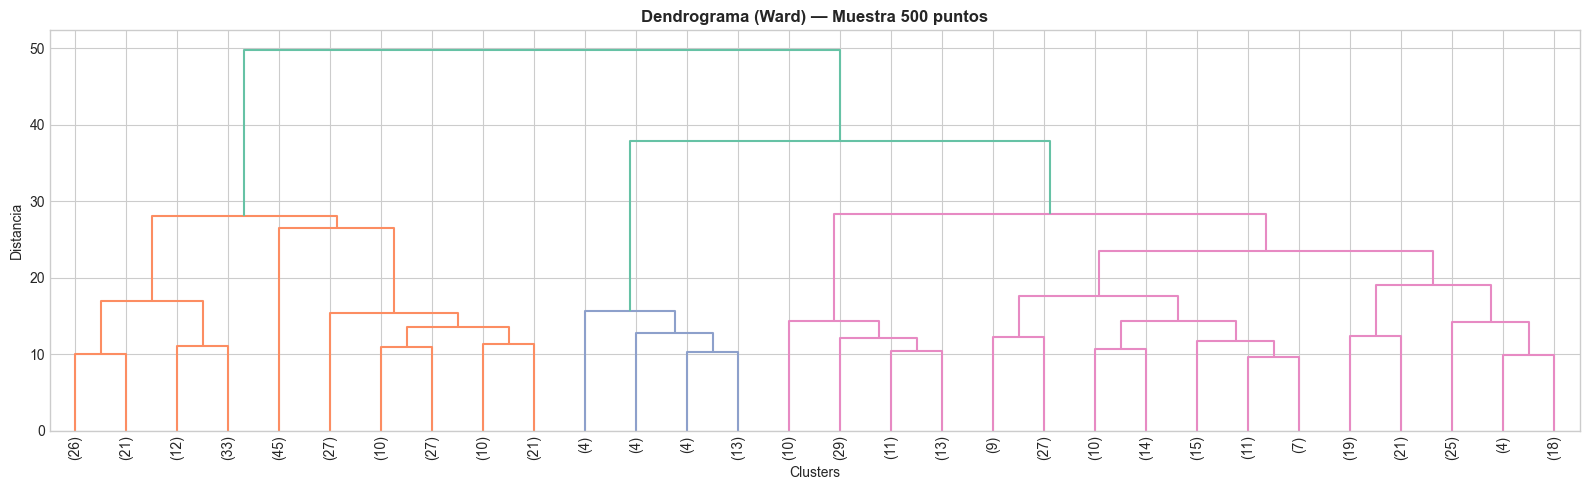

In [97]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

SAMPLE_SIZE = min(500, len(X_prep))
np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(len(X_prep), SAMPLE_SIZE, replace=False)
X_sample = X_prep[idx_sample]

Z = scipy_linkage(X_sample, method='ward')
fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title(f'Dendrograma (Ward) — Muestra {SAMPLE_SIZE} puntos', fontweight='bold')
ax.set_xlabel('Clusters'); ax.set_ylabel('Distancia')
plt.tight_layout(); plt.show()


### 2.2.2 Busqueda de Hiperparametros — Linkage × n_clusters

,linkage,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
7,complete,2,0.8284,64.03,0.1215
14,average,2,0.8284,64.03,0.1215
8,complete,3,0.5401,159.24,0.5700
15,average,3,0.4904,188.83,0.6785
16,average,4,0.4762,128.33,0.9303
17,average,5,0.4524,101.32,1.0498
9,complete,4,0.2971,208.04,1.1611
18,average,6,0.2048,81.99,1.2184
19,average,7,0.1505,68.66,1.1438
20,average,8,0.1504,59.08,1.0481


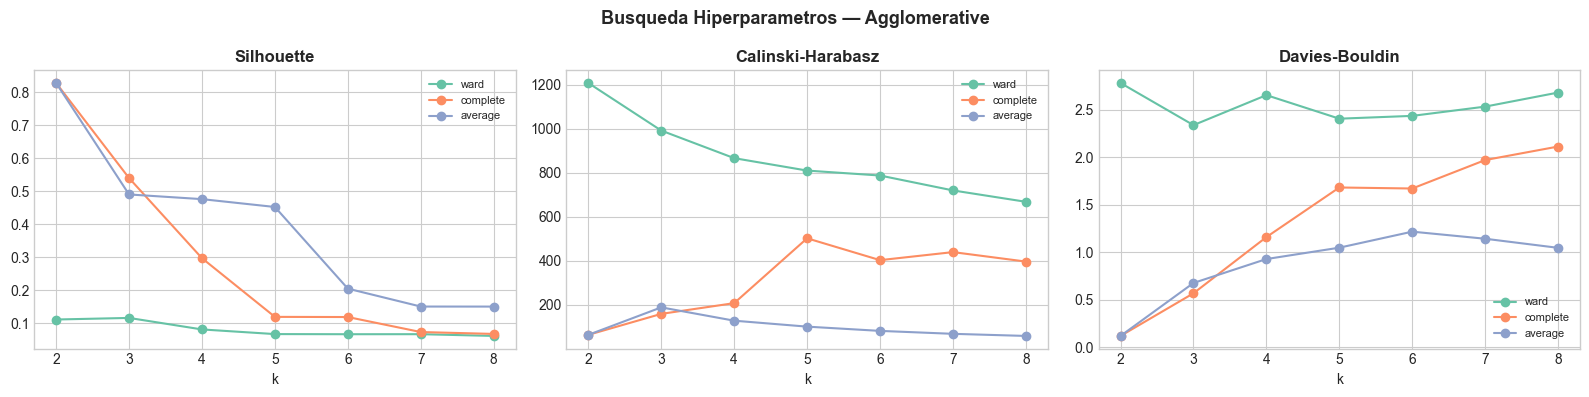


Mejor: linkage='complete', k=2  (Silhouette=0.8284)


In [98]:
LINKAGES = ['ward', 'complete', 'average']
K_RANGE_AGG = range(2, 9)
resultados_agg = []

for link in LINKAGES:
    for k in K_RANGE_AGG:
        try:
            labels_agg_tmp = AgglomerativeClustering(n_clusters=k, linkage=link).fit_predict(X_prep)
            sil = silhouette_score(X_prep, labels_agg_tmp)
            ch  = calinski_harabasz_score(X_prep, labels_agg_tmp)
            db  = davies_bouldin_score(X_prep, labels_agg_tmp)
            resultados_agg.append({'linkage': link, 'k': k,
                'Silhouette': round(sil,4), 'Calinski-Harabasz': round(ch,2), 'Davies-Bouldin': round(db,4)})
        except Exception as e:
            print(f"  Error {link} k={k}: {e}")

df_agg_search = pd.DataFrame(resultados_agg)
display(df_agg_search.sort_values('Silhouette', ascending=False).head(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['Silhouette','Calinski-Harabasz','Davies-Bouldin']):
    for link in LINKAGES:
        sub = df_agg_search[df_agg_search['linkage']==link]
        ax.plot(sub['k'], sub[metric], 'o-', label=link)
    ax.set_xlabel('k'); ax.set_title(metric, fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('Busqueda Hiperparametros — Agglomerative', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best_agg = df_agg_search.loc[df_agg_search['Silhouette'].idxmax()]
best_k_agg = int(best_agg['k']); best_link_agg = best_agg['linkage']
print(f"\nMejor: linkage='{best_link_agg}', k={best_k_agg}  (Silhouette={best_agg['Silhouette']:.4f})")


### 2.2.3 Entrenamiento del Modelo Final Agglomerative

In [99]:
# AgglomerativeClustering no tiene predict(), se aplica directamente sobre X_prep.
# El pipeline de preprocesamiento queda documentado y reutilizable para nuevos datos.
agg_best = AgglomerativeClustering(n_clusters=best_k_agg, linkage=best_link_agg)
agg_labels = agg_best.fit_predict(X_prep)

print(f"Agglomerative Clustering entrenado.")
print(f"  n_clusters={best_k_agg} | linkage='{best_link_agg}'")


Agglomerative Clustering entrenado.
  n_clusters=2 | linkage='complete'


### 2.2.4 Evaluacion y Visualizacion Agglomerative


  Agglomerative (k=2, complete)
  Clusters encontrados : 2
  Puntos ruido (-1)    : 0  (0.0%)
  Silhouette Score     : 0.8284
  Calinski-Harabasz    : 64.03
  Davies-Bouldin       : 0.1215

  Distribucion de clusters:
    Cluster 0: 9,999 (100.0%)
    Cluster 1: 1 (0.0%)


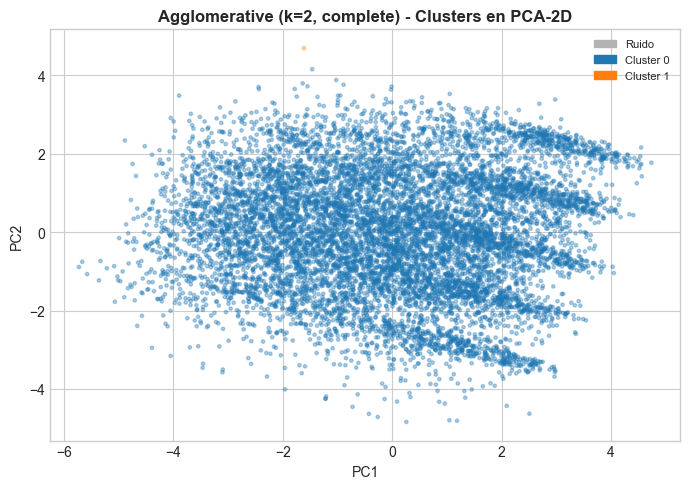

In [100]:
res_agg = evaluar_modelo(
    f'Agglomerative (k={best_k_agg}, {best_link_agg})', agg_labels, X_prep, X_pca2,
    satisfaction_ref if 'satisfaction_ref' in vars() else None
)
resultados['Agglomerative'] = res_agg


### 2.2.5 Perfiles de Clusters Agglomerative

Cluster_Agg,0,1
Age,39.40,53.0
Flight Distance,1195.92,2418.0
Inflight wifi service,2.73,3.0
Departure/Arrival time convenient,3.07,4.0
Ease of Online booking,2.76,4.0
Gate location,3.00,4.0
Food and drink,3.22,3.0
Online boarding,3.23,3.0
Seat comfort,3.43,3.0
Inflight entertainment,3.36,3.0


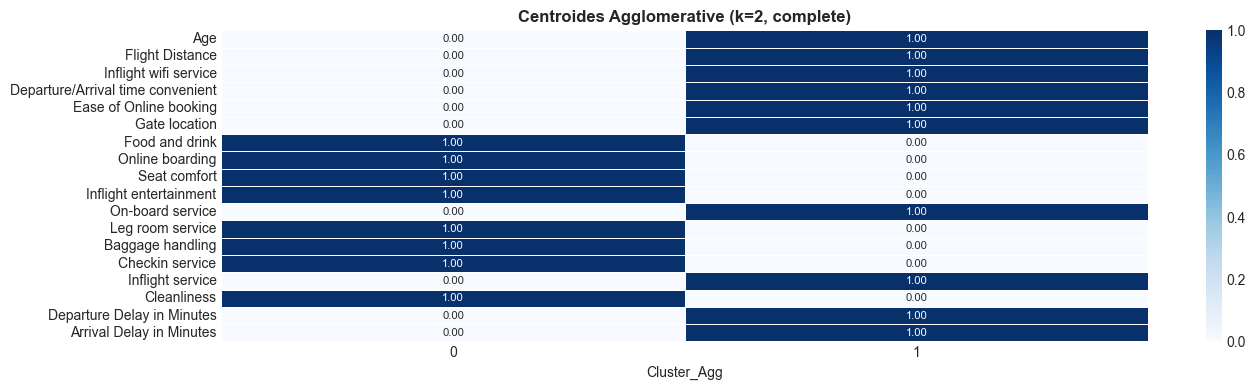

In [101]:
df_perfiles['Cluster_Agg'] = agg_labels
display(df_perfiles.groupby('Cluster_Agg')[COLS_NUM_CONT].mean().round(2).T)

centroids_agg = df_perfiles.groupby('Cluster_Agg')[COLS_NUM_CONT].mean()
centroids_agg_norm = pd.DataFrame(scaler_viz.fit_transform(centroids_agg),
    columns=COLS_NUM_CONT, index=centroids_agg.index)
fig, ax = plt.subplots(figsize=(14, max(4, best_k_agg)))
sns.heatmap(centroids_agg_norm.T, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Centroides Agglomerative (k={best_k_agg}, {best_link_agg})', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Modelo 3 — DBSCAN

### Descripcion teorica

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) agrupa puntos densamente concentrados sin necesitar *k* a priori. Clasifica cada punto como **core**, **border** o **ruido (−1)**.

**Restricciones y limitaciones:**
- Muy sensible a los hiperparametros `eps` y `min_samples`.
- No funciona bien con clusters de densidades muy distintas.
- En alta dimensionalidad la nocion de distancia se degrada (*curse of dimensionality*).
- No tiene `predict()` nativo para nuevos datos.

**Estrategia:** k-distance plot para estimar `eps`; grid search sobre eps x min_samples.


### 2.3.1 Seleccion de eps — k-Distance Plot

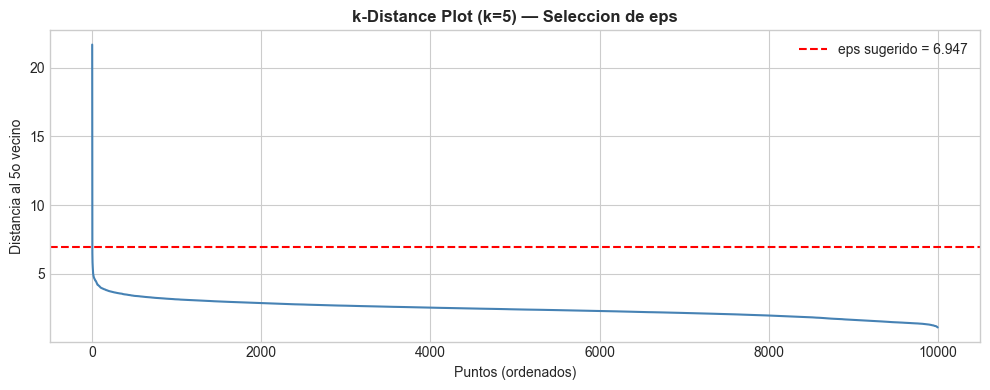

eps sugerido por el codo: 6.947


In [102]:
MIN_SAMPLES_DEFAULT = 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES_DEFAULT).fit(X_prep)
distances, _ = nbrs.kneighbors(X_prep)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color='steelblue')
ax.set_xlabel('Puntos (ordenados)'); ax.set_ylabel(f'Distancia al {MIN_SAMPLES_DEFAULT}o vecino')
ax.set_title(f'k-Distance Plot (k={MIN_SAMPLES_DEFAULT}) — Seleccion de eps', fontweight='bold')

segunda_deriv = np.diff(np.diff(k_distances))
codo_idx = np.argmax(np.abs(segunda_deriv)) + 1
eps_sugerido = round(k_distances[codo_idx], 3)
ax.axhline(eps_sugerido, color='red', linestyle='--', label=f'eps sugerido = {eps_sugerido}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"eps sugerido por el codo: {eps_sugerido}")


### 2.3.2 Busqueda de Hiperparametros — Grid eps x min_samples

In [103]:
EPS_RANGE         = [round(eps_sugerido * f, 3) for f in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]]
MIN_SAMPLES_RANGE = [3, 5, 10, 15]
resultados_dbscan = []

for eps_val in EPS_RANGE:
    for ms in MIN_SAMPLES_RANGE:
        labels_db_tmp = DBSCAN(eps=eps_val, min_samples=ms).fit_predict(X_prep)
        n_cl = len(set(labels_db_tmp)) - (1 if -1 in labels_db_tmp else 0)
        n_ru = (labels_db_tmp == -1).sum()
        mask = labels_db_tmp != -1
        if n_cl >= 2 and mask.sum() > 10:
            sil = round(silhouette_score(X_prep[mask], labels_db_tmp[mask]), 4)
            ch  = round(calinski_harabasz_score(X_prep[mask], labels_db_tmp[mask]), 2)
            db  = round(davies_bouldin_score(X_prep[mask], labels_db_tmp[mask]), 4)
        else:
            sil = ch = db = np.nan
        resultados_dbscan.append({'eps': eps_val, 'min_samples': ms, 'N Clusters': n_cl,
            '% Ruido': round(n_ru/len(labels_db_tmp)*100,1),
            'Silhouette': sil, 'Calinski-Harabasz': ch, 'Davies-Bouldin': db})

df_dbscan_search = pd.DataFrame(resultados_dbscan)
display(df_dbscan_search.sort_values('Silhouette', ascending=False).head(12))


,eps,min_samples,N Clusters,% Ruido,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,3.474,3,3,1.4,0.3217,17.98,0.7519
1,3.474,5,1,1.8,NaN,NaN,NaN
2,3.474,10,1,2.3,NaN,NaN,NaN
3,3.474,15,1,2.7,NaN,NaN,NaN
4,5.210,3,1,0.0,NaN,NaN,NaN
5,5.210,5,1,0.0,NaN,NaN,NaN
6,5.210,10,1,0.0,NaN,NaN,NaN
7,5.210,15,1,0.1,NaN,NaN,NaN
8,6.947,3,1,0.0,NaN,NaN,NaN
9,6.947,5,1,0.0,NaN,NaN,NaN


### 2.3.3 Seleccion de la mejor configuracion DBSCAN

In [104]:
df_dbscan_valid = df_dbscan_search[
    (df_dbscan_search['N Clusters'] >= 2) &
    (df_dbscan_search['% Ruido'] < 30) &
    (df_dbscan_search['Silhouette'].notna())
].copy()

if df_dbscan_valid.empty:
    print("Relajando filtro de ruido...")
    df_dbscan_valid = df_dbscan_search[df_dbscan_search['Silhouette'].notna()].copy()

best_row    = df_dbscan_valid.loc[df_dbscan_valid['Silhouette'].idxmax()]
best_eps    = best_row['eps']
best_ms     = int(best_row['min_samples'])
print(f"Mejor configuracion DBSCAN:")
print(f"  eps={best_eps} | min_samples={best_ms} | N Clusters={int(best_row['N Clusters'])} | % Ruido={best_row['% Ruido']}% | Silhouette={best_row['Silhouette']:.4f}")


Mejor configuracion DBSCAN:
  eps=3.474 | min_samples=3 | N Clusters=3 | % Ruido=1.4% | Silhouette=0.3217


### 2.3.4 Entrenamiento del Modelo Final DBSCAN

In [105]:
dbscan_best   = DBSCAN(eps=best_eps, min_samples=best_ms)
dbscan_labels = dbscan_best.fit_predict(X_prep)
n_cl_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN entrenado: eps={best_eps} | min_samples={best_ms} | N Clusters={n_cl_db}")


DBSCAN entrenado: eps=3.474 | min_samples=3 | N Clusters=3


### 2.3.5 Evaluacion y Visualizacion DBSCAN


  DBSCAN (eps=3.474, ms=3)
  Clusters encontrados : 3
  Puntos ruido (-1)    : 141  (1.4%)
  Silhouette Score     : 0.3217
  Calinski-Harabasz    : 17.98
  Davies-Bouldin       : 0.7519

  Distribucion de clusters:
    Ruido: 141 (1.4%)
    Cluster 0: 9,853 (98.5%)
    Cluster 1: 3 (0.0%)
    Cluster 2: 3 (0.0%)


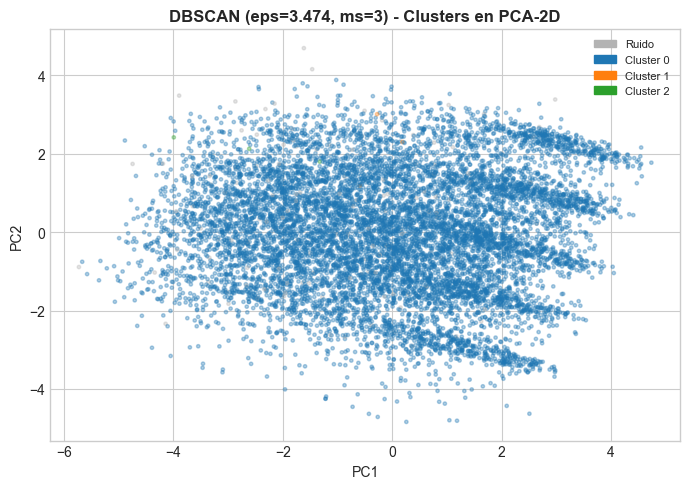

In [106]:
res_dbscan = evaluar_modelo(
    f'DBSCAN (eps={best_eps}, ms={best_ms})', dbscan_labels, X_prep, X_pca2,
    satisfaction_ref if 'satisfaction_ref' in vars() else None
)
resultados['DBSCAN'] = res_dbscan


### 2.3.6 Perfiles de Clusters DBSCAN

Cluster_DBSCAN,0,1,2
Age,39.42,45.67,21.67
Flight Distance,1193.07,973.00,609.00
Inflight wifi service,2.74,3.33,3.00
Departure/Arrival time convenient,3.08,4.00,3.00
Ease of Online booking,2.77,4.00,3.00
Gate location,3.00,4.33,3.67
Food and drink,3.22,3.33,3.00
Online boarding,3.24,3.33,2.33
Seat comfort,3.44,3.00,2.00
Inflight entertainment,3.37,2.67,1.33


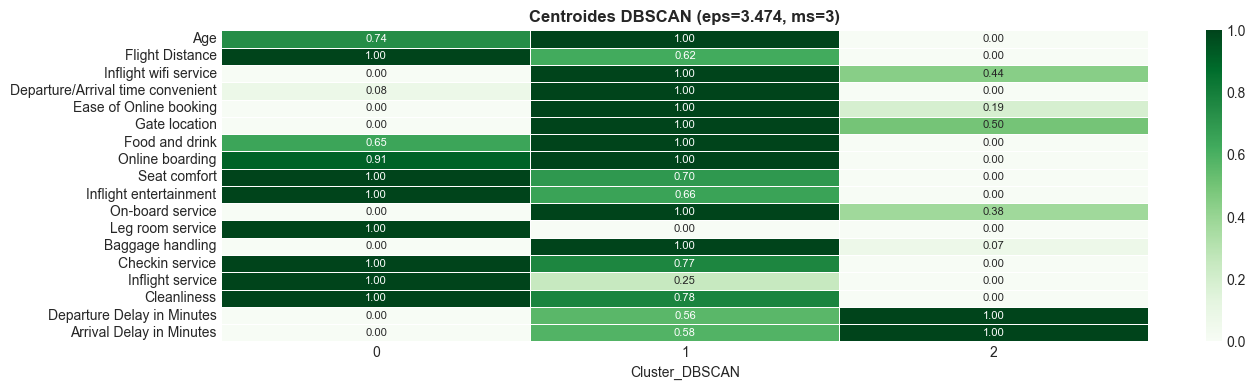

In [107]:
df_perfiles['Cluster_DBSCAN'] = dbscan_labels
df_dbscan_clean = df_perfiles[df_perfiles['Cluster_DBSCAN'] != -1]
display(df_dbscan_clean.groupby('Cluster_DBSCAN')[COLS_NUM_CONT].mean().round(2).T)

centroids_db = df_dbscan_clean.groupby('Cluster_DBSCAN')[COLS_NUM_CONT].mean()
if not centroids_db.empty:
    centroids_db_norm = pd.DataFrame(scaler_viz.fit_transform(centroids_db),
        columns=COLS_NUM_CONT, index=centroids_db.index)
    fig, ax = plt.subplots(figsize=(14, max(4, len(centroids_db))))
    sns.heatmap(centroids_db_norm.T, annot=True, fmt='.2f', cmap='Greens',
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'Centroides DBSCAN (eps={best_eps}, ms={best_ms})', fontweight='bold')
    plt.tight_layout(); plt.show()


---
## 4. Tabla Comparativa — Evaluacion Cuantitativa

| Metrica | Interpretacion | Mejor valor |
|---|---|---|
| Silhouette Score | Cohesion y separacion de clusters | Mayor (max. 1) |
| Calinski-Harabasz | Varianza inter/intra cluster | Mayor |
| Davies-Bouldin | Similitud promedio entre clusters | Menor |


,Hiperparametros,N Clusters,N Ruido,Silhouette,Calinski-Harabasz,Davies-Bouldin
Algoritmo,,,,,,
K-Means (k=2),"k=2, n_init=10",2,0,0.1404,1644.83,2.3789
"Agglomerative (k=2, complete)","k=2, linkage=complete",2,0,0.8284,64.03,0.1215
"DBSCAN (eps=3.474, ms=3)","eps=3.474, min_samples=3",3,141,0.3217,17.98,0.7519



Mejor Silhouette       : Agglomerative (k=2, complete)
Mejor Calinski-Harabasz: K-Means (k=2)
Mejor Davies-Bouldin   : Agglomerative (k=2, complete)


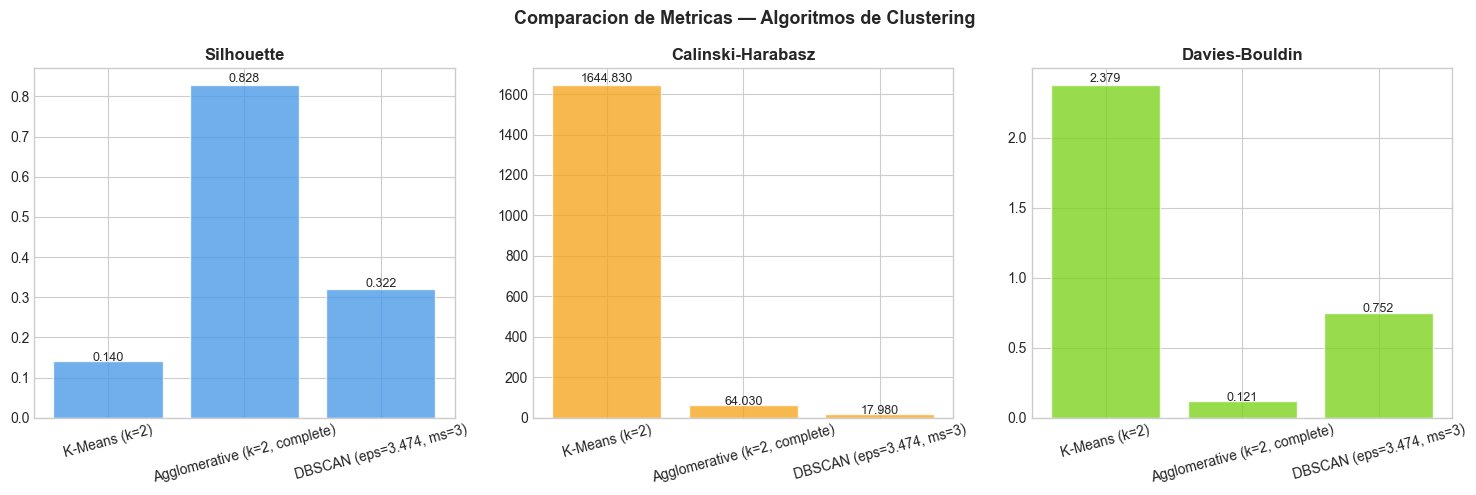

In [108]:
df_comparativa = pd.DataFrame(list(resultados.values()))
hp_map = {
    'K-Means':       f'k={best_k}, n_init=10',
    'Agglomerative': f'k={best_k_agg}, linkage={best_link_agg}',
    'DBSCAN':        f'eps={best_eps}, min_samples={best_ms}'
}
# Coincide clave con nombre completo (usar startswith)
def get_hp(nombre):
    for k,v in hp_map.items():
        if k in nombre: return v
    return '-'
df_comparativa['Hiperparametros'] = df_comparativa['Algoritmo'].apply(get_hp)
cols_tabla = ['Algoritmo','Hiperparametros','N Clusters','N Ruido','Silhouette','Calinski-Harabasz','Davies-Bouldin']
df_comparativa = df_comparativa[cols_tabla]
display(df_comparativa.set_index('Algoritmo'))

print("\nMejor Silhouette       :", df_comparativa.loc[df_comparativa['Silhouette'].idxmax(), 'Algoritmo'])
print("Mejor Calinski-Harabasz:", df_comparativa.loc[df_comparativa['Calinski-Harabasz'].idxmax(), 'Algoritmo'])
print("Mejor Davies-Bouldin   :", df_comparativa.loc[df_comparativa['Davies-Bouldin'].idxmin(), 'Algoritmo'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas_viz = [('Silhouette','#4C9BE8'), ('Calinski-Harabasz','#F5A623'), ('Davies-Bouldin','#7ED321')]
for ax, (metric, color) in zip(axes, metricas_viz):
    vals = df_comparativa[metric].fillna(0)
    bars = ax.bar(df_comparativa['Algoritmo'], vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'{val:.3f}', ha='center', fontsize=9)
plt.suptitle('Comparacion de Metricas — Algoritmos de Clustering', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Seleccion y Justificacion del Mejor Modelo

> **[COMPLETAR DESPUES DE EJECUTAR Y VER LOS RESULTADOS REALES]**

Con base en la tabla anterior, el modelo seleccionado es **[ALGORITMO]** porque:
- Obtuvo el mayor Silhouette Score (**[valor]**), indicando clusters bien definidos y separados.
- El numero de clusters (**[k]**) es interpretable para los objetivos de VuelaAlpes.

Las restricciones que afectaron a los demas:
- **K-Means:** asume clusters esfericos; puede no capturar formas complejas de comportamiento de pasajeros.
- **Agglomerative:** mayor costo computacional y sin capacidad de prediccion para nuevos pasajeros.
- **DBSCAN:** en espacios de alta dimensionalidad la densidad se degrada; muy sensible a `eps`.


# 5. Evaluación cualitativa

# 6. Análisis de Resultados

1. ¿Qué restricciones tiene cada uno de los algoritmos seleccionados? ¿Cómo afectan estas restricciones la calidad de la solución obtenida?

2. ¿Qué criterios son importantes para la selección del algoritmo?

3. ¿Cómo medir la calidad del modelo construido? ¿Cómo saber que el modelo construido tiene una buena calidad? 

4. ¿Cómo varía la calidad de la solución obtenida si se aplican diferentes algoritmos?

5. ¿Cómo interpretar el resultado de la ejecución de los algoritmos de agrupación seleccionados?

# 7. Video

Video Recomendaciones[]

# 8. Registro del uso de IA generativa